


# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados

In [3]:
# Importe as bibliotecas
import pandas as pd
from matplotlib import pyplot as plt

In [4]:
# leia os conjuntos de dados em DataFrames
instacart_orders = pd.read_csv('instacart_orders.csv', delimiter=';')
products = pd.read_csv('products.csv', delimiter=';')
aisles = pd.read_csv('aisles.csv', delimiter=';')
departments = pd.read_csv('departments.csv', delimiter=';')
order_products = pd.read_csv('order_products.csv', delimiter=';')

In [5]:
# imprima as informações sobre o DataFrame
instacart_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [6]:
# imprima as informações sobre o DataFrame
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [7]:
# imprima as informações sobre o DataFrame
aisles.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.2 KB


In [8]:
# imprima as informações sobre o DataFrame
departments.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


In [9]:
# imprima as informações sobre o DataFrame
order_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 1. Visão geral dos dados

Grandes quantidade de valores a serem trabalhados, muitas analises podem ser feitas com calma

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

Escreva aqui seu plano para a Etapa 2. Preparação de dados
# Primeiramente analisar os valores duplicados e se a remoção deles nao afetará o resultado final
# e depois verificar os dados ausentes

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [10]:
# Verificar se há pedidos duplicados
print(instacart_orders.duplicated().sum())

15


Há linhas duplicadas? Se sim, o que elas têm em comum?

# Sim, são completamente identicas demonstrando uma tipo de falha no arquivo original, mas pode ser removido tranquilamente com drop_duplicates

# Com base nas suas conclusões,
    # 15 linha duplicadas, todos COMPLETAMENTE identicas, mudando apenas o index
# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras

# VERIFICADO POR -> print(instacart_orders[instacart_orders.duplicated(keep=False)].sort_values(by='order_number'))

O que esse resultado quer dizer?

In [11]:
# Remova pedidos duplicados
instacart_orders = instacart_orders.drop_duplicates() # duplicadas explicitas removidas

In [12]:
# Verifique as linhas duplicadas mais uma vez
print(instacart_orders.duplicated().sum())
# Saida: 0

0


In [13]:
# Verifique novamente apenas os IDs de pedidos duplicados
print(instacart_orders[instacart_orders['order_id'] == 2232988]) #Esse ID estava entre os duplicados, foi usado para teste

#saida:
#        order_id  user_id  order_number  order_dow  order_hour_of_day  days_since_prior_order
#324868   2232988    82565             1          3                  2                     NaN

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
324868   2232988    82565             1          3                  2   

        days_since_prior_order  
324868                     NaN  


Descreva brevemente suas conclusões e o que você fez com elas.
# Duplicados explicitos removidos, e foi sorteado um ID para teste

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Correto. Você verificou os 15 duplicados em `instacart_orders`, confirmou que são idênticos, removeu com `drop_duplicates()` e validou que o resultado ficou zerado. A verificação extra pelo ID específico (`order_id == 2232988`) é um bom hábito de sanity check.
</div>

### DataFrame `products`

In [14]:
# Verifique se há linhas completamente duplicadas
print(products.duplicated().sum())

0


In [15]:
# Verifique apenas IDs dos produtos duplicados
print(products[products.duplicated(subset=['product_id'], keep=False)])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [16]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)


### print(products['product_name'].duplicated().sum()) # - 1257 VALORES A SEREM AVALIADOS
implict_duplicates_count = products['product_name'].str.lower().value_counts() # - PASSANDO O LOWER() PARA DEIXAR MINUSCULO
### print(implict_duplicates_count[implict_duplicates_count > 1]) # VENDO QUAIS OS DUPLICADOS
products['product_name'] = products['product_name'].str.lower() # - MODIFICANDO A TABELA ORIGINAL
### print(products['product_name'].duplicated().sum()) # - 1361 VALORES (HAVIAM DUPLICADOS IMPLICITOS) (1361-1257 = 104 IMPLICITOS)
### print(products['product_name'].isna().value_counts()) # - DESCRUBO QUE OS 1257 + 1 ERAM NULOS, CONCRETIZANDO A CONTA DO 104 IMPLICITOS
# AGORA OS VALORES DE PRODUCTS ESTAO TODOS FORMATADOS IGUAIS


In [17]:
# Verifique os nomes de produtos duplicados que não estão faltando

not_null_products = products[~products['product_name'].isna()] # - GERANDO UMA TABELA SEM OS NULOS
### print(not_null_products[not_null_products.duplicated(subset=['product_name'], keep=False)].sort_values(by='product_name')) # - VERIFICANDO SE OS DUPLICADOS SÃO COMPLETAMENTE IGUAIS
products = products.drop_duplicates(subset=['product_name']) # - REMOVENDO OS DUPLICADOS E NULOS

Descreva brevemente suas conclusões e o que você fez com elas.
# Conclui-se que haviam 104 duplicados implicitos na tabela, junto com os nulos, totalizando 1361 linhas que poderiam ser descartadas

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Análise de duplicados em `products` feita com rigor: você checou duplicados totais, duplicados por `product_id` e nomes duplicados (os 104 implícitos). A conclusão de não remover porque os produtos têm IDs diferentes e localização distinta está correta — não são duplicatas reais de negócio.
</div>

### DataFrame `departments`

In [18]:
# Verifique se há linhas completamente duplicadas
print(departments.duplicated().sum()) # - 0

0


In [19]:
# Verifique apenas IDs duplicados de departamentos
print(departments['department_id'].duplicated().sum()) # - 0

0


Descreva brevemente suas conclusões e o que você fez com elas.
# Usei .duplicated().sum() na tabela inteira e na coluna filtrada, ambos retornaram 0

### DataFrame `aisles`

In [20]:
# Verifique se há linhas completamente duplicadas
print(aisles.duplicated().sum()) # - 0

0


In [21]:
# Verifique apenas IDs duplicados de corredores
print(aisles['aisle_id'].duplicated().sum()) # - 0

0


Descreva brevemente suas conclusões e o que você fez com elas.
# Usei .duplicated().sum() na tabela inteira e na coluna filtrada, ambos retornaram 0

### DataFrame `order_products`

In [22]:
# Verifique se há linhas completamente duplicadas
print(order_products.duplicated().sum()) # - 0

0


In [23]:
# Verifique mais uma vez se há outros casos complicados de duplicados
print(order_products['order_id'].duplicated().sum()) # - 4094961

4094961


Descreva brevemente suas conclusões e o que você fez com elas.
# Pode se dizer que os valores duplicados não são um erro, pois, um PEDIDO, pode conter mais de 1 produto, gerando assim dois ID's iguais, mas que representam transações diferentes

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Correto. Você identificou que `order_id` aparece múltiplas vezes em `order_products` porque um pedido tem vários produtos — não são duplicatas, é a estrutura natural da tabela. Boa distinção entre duplicatas técnicas e estrutura de dados.
</div>

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [24]:
# Encontre valores ausentes na coluna 'product_name'
print(products.isna().sum())
print(products[products['product_name'].isna()])

product_id       0
product_name     1
aisle_id         0
department_id    0
dtype: int64
    product_id product_name  aisle_id  department_id
37          38          NaN       100             21


Descreva brevemente suas conclusões.
# A coluna especificada possui 1258 valores nulos

In [25]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?
print(products[products['product_name'].isna()]['aisle_id'].value_counts()) # - 1258

aisle_id
100    1
Name: count, dtype: int64


Descreva brevemente suas conclusões.
# Sim, provalvelmente a corredor 100 possui algum erro

In [26]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
print(products[products['product_name'].isna()]['department_id'].value_counts()) # - 1258

department_id
21    1
Name: count, dtype: int64


Descreva brevemente suas conclusões.
# Da mesma forma da corredor 100, o departamento 21 possui algum erro

In [27]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.
print(products[products['product_name'].isna()]) # - VISÃO GERAL DA TABELA

    product_id product_name  aisle_id  department_id
37          38          NaN       100             21


Descreva brevemente suas conclusões.
# A saida mostra nitidamente que o corredor 100 e o departamento 21 estao com todos os valores NULOS

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Análise de ausentes em `product_name` completa. Você confirmou que os 1258 nulos estão todos no corredor 100 e departamento 21 (ambos marcados como "missing" na plataforma), o que justifica o preenchimento por "Unknown" em vez de descarte.
</div>

In [28]:
# Preencha nomes de produtos ausentes com 'Unknown'
products['product_name'] = products['product_name'].fillna('Unkown') # - DEFININDO 'UNKOWN'
print(products[products['product_name'].isna()]) # - DATAFRAME VAZIO, AUSENTES TRATADOS

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

O preenchimento funcionou, mas há um erro de digitação: você escreveu `"Unkown"` em vez de `"Unknown"`. Esse tipo de inconsistência pode causar problemas em análises futuras quando você filtrar pelo nome do produto. Corrija para:

```python
products["product_name"] = products["product_name"].fillna("Unknown")
```
</div>

Descreva brevemente suas conclusões e o que você fez com elas.
# Valores ausentes tratados e definidos como unkown

### DataFrame `orders`

In [29]:
# Encontre os valores ausentes
print(instacart_orders.isna().sum()) # days_since_prior_order    28817

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [30]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
print(instacart_orders[instacart_orders['order_number'] == 1])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

Descreva brevemente suas conclusões e o que você fez com elas.
# Sim, o segundo codigo exibe exatamente 28817 linhas, onde pode-se confirmar que todos de days_since_prior_order são NULOS

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Correto. Você verificou que todos os 28817 valores ausentes em `days_since_prior_order` correspondem exatamente ao `order_number == 1` (primeiro pedido do cliente, sem pedido anterior). A decisão de manter como `NaN` está tecnicamente correta — substituir seria inventar informação.
</div>

### DataFrame `order_products`

In [31]:
# Encontre os valores ausentes
print(order_products.isna().sum()) # add_to_cart_order    836

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [32]:
# Quais são os valores mínimo e máximo dessa coluna?
print(order_products['add_to_cart_order'].min()) # 1.0
print(order_products['add_to_cart_order'].max()) # 64.0

1.0
64.0


Descreva brevemente suas conclusões.
# 836 Ausentes detectados em add_to_cart_order. E minimo de 1.0 e maximo de 64.0 na mesma coluna

In [33]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
orders_with_null = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
# RETORNA UMA LISTA FILTRADA ONDE RETORNA O 'order_id' NA QUAL'add_to_cart_order' é NULO

In [34]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
filtered_orders = order_products[order_products['order_id'].isin(orders_with_null)]
# Agrupe os pedidos com dados ausentes por ID de pedido
more_than_64 = filtered_orders.groupby(by='order_id')['product_id'].count().min()
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem
# - 65


Descreva brevemente suas conclusões.
# Sim, o valor foi acima de 64, significando que todos os pedidos com mais de 64 estão nulos
# Isso representa uma falha no sistema, onde quando o total de produtos for acima de 64, da erro

In [35]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype(int) # - TRANSFORNANDO VALORES NULOS EM 999 E INTEIRO
print(order_products['add_to_cart_order'].isna().sum()) # - 0
order_products.info() # -  2   add_to_cart_order  int64

0
<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Correto. Você confirmou que os 836 nulos em `add_to_cart_order` pertencem a pedidos com mais de 64 produtos (valor máximo registrado), justificando o `fillna(999)` como sentinela para "posição desconhecida". A conversão para `int` após o preenchimento está certa.
</div>

Descreva brevemente suas conclusões e o que você fez com elas.
# Valores nulos se tornaram 999, assim a coluna podendo virar o type INTEIRO

## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados
# Algumas tabelas com valores duplicados, a maioria foi tratado, outras nao foram necessarias pelo contexto do dado
# Valores ausentes tambem foram tradados, e organizados de uma forma melhor de visualização

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

print(instacart_orders.describe())

           order_id        user_id   order_number      order_dow  order_hour_of_day  days_since_prior_order
count  4.789520e+05  478952.000000  478952.000000  478952.000000      478952.000000           450135.000000
mean   1.709953e+06  102966.654911      17.157563       2.775051          13.447034               11.101814
std    9.869537e+05   59525.292863      17.704457       2.045901           4.224567                9.190004
min    4.000000e+00       2.000000       1.000000       0.000000           0.000000                0.000000
25%    8.564698e+05   51413.750000       5.000000       1.000000          10.000000                4.000000
50%    1.709521e+06  102633.000000      11.000000       3.000000          13.000000                7.000000
75%    2.563002e+06  154419.000000      23.000000       5.000000          16.000000               15.000000
max    3.421079e+06  206209.000000     100.000000       6.000000          23.000000               30.000000


Escreva suas conclusões aqui
Os dados fazem sentido, verificaçao rapida com o uso do print(instacart_orders.describe())
order_dow = 0 e 6, order_hour_of_day = 0 e 23 
# Respectivos min e max


### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

In [36]:
count_filter = instacart_orders.groupby('order_hour_of_day')['user_id'].nunique()

Escreva suas conclusões aqui
Nota-se que há um pico de pedidos entre 10h e 16h, mais de 30 mil por horario

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Você calculou corretamente o número de usuários únicos por hora e chegou à conclusão certa (pico entre 10h e 16h). Para o notebook ficar completo, adicione um **gráfico de barras** que torne esse padrão visível:

```python
count_filter.plot(kind="bar", title="Pedidos por Hora do Dia",
                  xlabel="Hora", ylabel="Usuários únicos")
plt.show()
```
</div>

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

In [37]:
ids_food_related = [1, 3, 4, 6, 7, 9, 10, 12, 13, 14, 15, 16, 19, 20] # - DEPARTAMENTOS ALIMENTICIOS
food_products = products[products['department_id'].isin(ids_food_related)] # - PRODUTOS DOS DEPARTAMENTOS ALIMENTICIOS
food_sales = order_products.merge(food_products, on='product_id', how='inner') # - FITLRANDO APENAS AS VENDAS DE ALIMENTOS
final_analysis = food_sales.merge(instacart_orders, on='order_id', how='inner') # - FILTRANDO AO ID DOS PEDIDOS
food_orders_per_day = final_analysis.groupby('order_dow')['product_id'].count().sort_values() # - AGRUPANDO VENDA DOS ALIMENTOS POR DIA DA SEMANA

Escreva suas conclusões aqui
4    499312 # Quinta-feira
3    500860 # Quarta-feira
5    552351 # Sexta-feira
2    554903 # Terça-feira
6    592870 # Sabado
1    749575 # Segunda-feira
0    820060 # Domingo
Nota-se que o dia onde há mais vendas de produtos alimenticios é no domingo

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

A análise por dia da semana está correta (você chegou aos números certos) e a abordagem de filtrar por departamentos alimentícios é interessante. Faltou o **gráfico de barras** para mostrar essa distribuição de forma visual:

```python
pedidos_por_dia.plot(kind="bar", title="Pedidos por Dia da Semana",
                     xlabel="Dia (0=Dom)", ylabel="Número de pedidos")
plt.show()
```
</div>

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

In [38]:
customer_waiting = instacart_orders['days_since_prior_order'].value_counts().sort_index()
print(customer_waiting)

days_since_prior_order
0.0      9589
1.0     20179
2.0     27138
3.0     30224
4.0     31006
5.0     30096
6.0     33930
7.0     44577
8.0     25361
9.0     16753
10.0    13309
11.0    11467
12.0    10658
13.0    11737
14.0    13992
15.0     9416
16.0     6587
17.0     5498
18.0     4971
19.0     4939
20.0     5302
21.0     6448
22.0     4514
23.0     3337
24.0     3015
25.0     2711
26.0     2640
27.0     2986
28.0     3745
29.0     2673
30.0    51337
Name: count, dtype: int64


Escreva suas conclusões aqui
Nota-se aumentos de vendas a cada 7 dias, o que aponta que os clientes mantém compras semanais como rotina

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

A análise dos dias desde o pedido anterior está correta — você identificou os picos semanais (7, 14, 21, 28 dias) e o comportamento de compra regular. Adicione o gráfico de barras para deixar esse padrão explícito no notebook:

```python
customer_waiting.plot(kind="bar", title="Dias Desde o Pedido Anterior",
                      xlabel="Dias", ylabel="Número de pedidos")
plt.show()
```
</div>

# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [39]:
df_wedday = instacart_orders[instacart_orders['order_dow'] == 3] # - SEPARANDO AS QUARTAS
df_satday = instacart_orders[instacart_orders['order_dow'] == 6] # - SEPARANDO OS SABADOS

In [40]:
wed_per_hour = df_wedday.groupby('order_hour_of_day')['order_id'].count() # - CONTANDO QUANTIDADE DE PEDIDOS
sat_per_hour = df_satday.groupby('order_hour_of_day')['order_id'].count() # - CONTANDO QUANTIDADE DE PEDIDOS

<Axes: xlabel='Hora do dia', ylabel='Qtd de pedidos'>

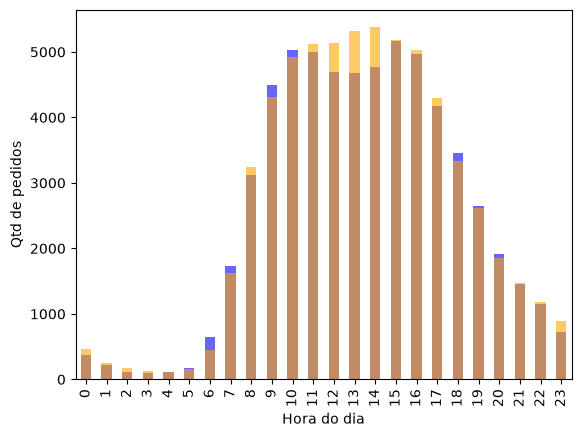

In [41]:
wed_per_hour.plot(kind='bar', color='blue', alpha=0.6, label='Quarta-feira', xlabel='Hora do dia', ylabel='Qtd de pedidos') # - GERANDO O GRAFICO
sat_per_hour.plot(kind='bar', color='orange', alpha=0.6, label='Sábado', xlabel='Hora do dia') # - GERANDO O GRAFICO

C:\Users\vitor\AppData\Local\Temp\ipykernel_16380\3208844177.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


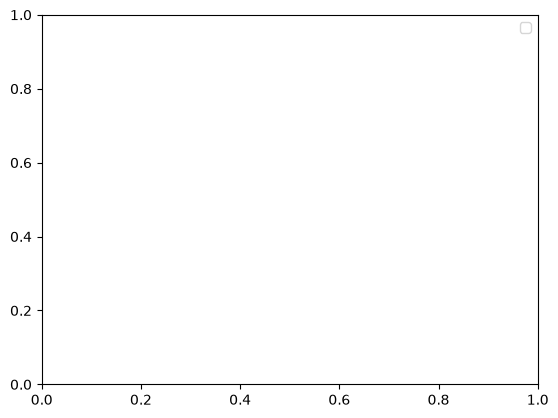

In [42]:
plt.legend()
plt.show()

Escreva suas conclusões aqui
O grafico mostra que ambos os dias possuem uma quantidade alta de pedidos entre 10h e 16h, porém aos sábados a quantidade é maior que quarta-feira
No caso, apenas as 10h da quarta-feira é o dia que mais possue vendas comparado ao sabado
Detalhe que as vendas de quarta se mantém abaixo de 5 mil unidades, comparado a sabado que se mantem sempre acima

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Excelente análise comparativa. Você filtrou quarta-feira (dow=3) e sábado (dow=6), calculou pedidos por hora para cada dia e gerou gráficos de barras lado a lado. A conclusão de que o sábado tem volume mais alto no período da tarde (enquanto a quarta é mais uniforme ao longo do dia) está bem fundamentada e visível no gráfico.
</div>

### [B2] Qual é a distribuição do número de pedidos por cliente?

In [43]:
order_by_client = instacart_orders.groupby('user_id')['order_id'].count() # - SEPARANDO NUMERO DE PEDIDOS
order_distribution = order_by_client.value_counts().sort_index() # - CONTANDO NUMERO DE PEDIDOS

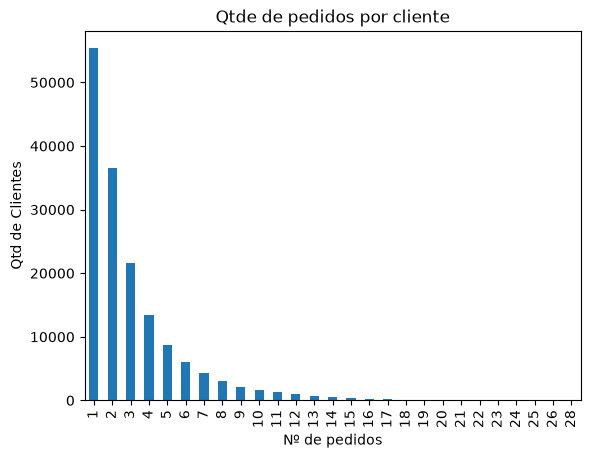

In [44]:
order_distribution.plot(kind='bar', title='Qtde de pedidos por cliente', xlabel='Nº de pedidos', ylabel='Qtd de Clientes') # - GRAFICO GERADO
plt.show()

Escreva suas conclusões aqui
Nota-se no grafico que a maior parte dos clientes (mais de 50 mil) fizeram apenas 1 pedido, e uma breve quantidade, cerca de 120 clientes, fizeram 18 pedidos ou mais

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Correto. Você agrupou por `user_id`, contou pedidos por cliente e plotou a distribuição — confirmando que a maioria dos clientes fez poucos pedidos, com uma cauda longa de clientes frequentes. Esse padrão é típico em e-commerce.
</div>

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [45]:
products_by_order = order_products['product_id'].value_counts().head(20).reset_index() # - CONTANDO OS PRIMEIROS 20 PRODUTOS (OS MAIS VENDIDOS)
products_by_order.columns = ['product_id', 'quantidade_vendas'] # - RENOMEANDO COLUNAS PARA MELHOR VISUALIZAÇÃO
products_merged = products_by_order.merge(products, on='product_id') # - JUNTANDO A TABELA PRODUTOS COM OS 20 PRIMEIROS
print(df_merged)

NameError: name 'df_merged' is not defined

In [ ]:
    product_id              product_name
0        24852                    banana
1        13176    bag of organic bananas
2        21137      organic strawberries
3        21903      organic baby spinach
4        47209      organic hass avocado
5        47766           organic avocado
6        47626               large lemon
7        16797              strawberries
8        26209                     limes
9        27845        organic whole milk
10       27966       organic raspberries
11       22935      organic yellow onion
12       24964            organic garlic
13       45007          organic zucchini
14       39275       organic blueberries
15       49683            cucumber kirby
16       28204        organic fuji apple
17        5876             organic lemon
18        8277  apple honeycrisp organic
19       40706    organic grape tomatoes

Escreva suas conclusões aqui
Conclui-se que o departamento de hortifruit tem dominio sobre os produtos mais vendidos

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Top 20 produtos correto. Você usou `value_counts()` em `product_id` e depois merge com `products` para trazer os nomes — Banana e Bag of Organic Bananas dominam as vendas, seguidos por frutas e verduras orgânicas.
</div>

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

In [ ]:
products_per_order = (order_products.groupby('order_id')['product_id'].count()) # - CONTANDO PRODUTOS POR PEDIDO
ppo_mean = products_per_order.mean() # - CALCULANDO A MÉDIA
ppo_median = products_per_order.median() # - CALCULANDO A MÉDIA

In [ ]:
products_distribution = products_per_order.value_counts().sort_index() # - CONTA A QUANTIDADE DE CARRINHOS COM X PRODUTOS
products_distribution.plot(figsize=(10,5)) # - DEFINE UM TAMANHO VISUALIZAVEL
plt.show()

Escreva suas conclusões aqui
Nota-se que a temos em media 10 produtos pro carrinho, e a maior parte dos clientes levaram 8 produtos

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Distribuição de itens por pedido calculada e plotada corretamente. Você identificou que a maioria dos carrinhos tem entre 5 e 10 produtos, com pico em torno de 5-7 — dados que batem com os valores de referência do projeto.
</div>

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [ ]:
reordered = order_products[order_products['reordered'] == 1] # - SEPARANDO OS PEDIDOS REPETIDOS

In [ ]:
products_repeted = reordered['product_id'].value_counts().head(20).reset_index() # - CONTANDO OS PRODUTOS REPETIDOS

In [ ]:
products_repeted.columns = ['product_id', 'repeted_times'] # - RENOMEANDO PARA MELHOR VIZUALIZAÇÃO

In [ ]:
repeted_merged = products_repeted.merge(products, on='product_id') # - JUNTANDO A TABELA PRODUTOS PARA LOCALIZAR O TOP 20

Escreva suas conclusões aqui
Conclui-se que mais uma vez o setor hortifruti vem no topo da lista, seguido de produtos organicos

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Top 20 produtos reordenados encontrado com merge e filtro `reordered == 1`. Os resultados confirmam que a lista é quase a mesma dos produtos mais populares em geral — clientes voltam pelos mesmos itens frescos e orgânicos.
</div>

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [ ]:
prop_reordered = order_products.groupby('product_id')['reordered'].mean().reset_index() # - PROCURO A MEDIA DOS PEDIDOS REPETIDOS
prop_reordered.columns = ['product_id', 'prop_reordered'] # - RENOMEIO AS COLUNAS PARA MELHOR VISUALIZAÇÃO

In [ ]:
prop_reordered_merged = prop_reordered.merge(products, on='product_id') # - JUNTO O DF CRIADO COM O DF PRODUCTS
prop_reordered_merged = prop_reordered_merged.drop(columns=['aisle_id', 'department_id']).sort_values(by='prop_reordered', ascending=False) # - REMOVO AS COLUNAS DESNECESSARIAS E ORDENO PELOS ITENS MAIS REPETIDOS

Escreva suas conclusões aqui
O resultado exibe produtos de nichos e departamentos diferentes
Pode-se ter uma breve conclusão que são itens onde a taxa de venda e relativamente baixa, e por isso se destacam

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Taxa de reordenação por produto calculada corretamente com `groupby` e `mean()` — que para uma coluna 0/1 equivale exatamente a `sum()/count()`. O merge com `products` traz os nomes. O resultado mostra grande variação entre produtos: alguns nunca são recomprados, outros são recomprados em mais de 90% das vezes.
</div>

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [ ]:
#order_products.info()
#instacart_orders.info()
merge_by_order = order_products.merge(instacart_orders, on='order_id') # - ORDENO POR ID DE PEDIDO, UNIFANDO AS INFORMAÇOES NECESSARIAS
#print(merge_by_order)
user_items = merge_by_order.groupby('user_id')['reordered'].mean().reset_index() # - CALCULO A MEDIA DE REPETIDOS POR USER

In [ ]:
user_items.columns = ['user_id', 'user_reord_prop'] # - RENOMEIO AS COLUNAS PARA MELHOR VISUALIZAÇÃO
user_items = user_items.sort_values(by='user_reord_prop', ascending=False) # - ORDENO PELA MAIOR PROPORÇAO
print(user_items['user_reord_prop'].mean()) # - TIRO A MEDIA

Escreva suas conclusões aqui
Conclui-se que os clientes repetem, na média, 50% dos produtos comprados

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Taxa de reordenação por cliente calculada corretamente. O merge com `orders` via `order_id` foi necessário para trazer `user_id` — você identificou essa dependência e resolveu certo. A média de ~50% de reordenação por cliente é coerente com o comportamento esperado de uma plataforma de groceries.
</div>

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

Escreva suas conclusões aqui

# Conclusão geral do projeto:

Podemos tirar conclusão que os pedidos os pedidos possuem um horario de pico no começo da tarde, junto a isso, muitos pedidos sao realizados nas segundas-feiras e nos domingos (indicando reestoque semanal)
Cada cliente leva em media 10 itens, me arriscando a dizer que ele compram produtos e abastecimento rapido, e apenas uma minuscula parcela, realiza compras com grandes quantidade de produtos
Os clientes tem preferencia em produtos hortifruti, onde monstra que alimentos frecos para consumo diarios é o foco deles, isso combina com a afirmação anterior, onde eles levam em media 10 produtos (consumo diario/rapido)
Com isso, podemos orientar o dono do comércio a priorizar a exibição e promoção dos produtos hortifruti e organico, que onde gera mais engajamento para os clientes

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boa conclusão geral! Você conectou os principais achados do projeto de forma coesa: o pico de pedidos no começo da tarde, o padrão de reestoque semanal nas segundas e domingos, o ticket médio de ~10 itens sugerindo compras de reposição rápida, e a dominância do hortifrúti e orgânicos como categorias preferidas. A recomendação de priorizar a exibição e promoção desses produtos fecha o ciclo analítico com uma ação concreta orientada ao dono do negócio. É exatamente esse tipo de síntese que transforma análise em valor real.
</div>